# Alignment of the cerebellar

Align the cerebellar voxels better for use in regression - to look at changes only in the cerebellum.

Make sure that all names are for new files, not overwriting any present files (all in smarts_cerebellum directory)

In [1]:
# Imports

# model libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# image reading libraries
import nibabel as nib
from nilearn import plotting as npl
from nilearn import masking # for masking within-brain voxels

import nitools as nt

from pathlib import Path
import os

In [2]:
# directories
base_dir = '/cifs/diedrichsen/data/smarts_cerebellum'
anat_dir = '/cifs/diedrichsen/data/smarts_cerebellum/anatomicals'
p_df = pd.read_csv('/cifs/diedrichsen/data/smarts_cerebellum/participants_anat.tsv', sep = '\t')

In [3]:
# 1. get the cerebellar isolation mask (SUITPy pipeline) and the T1 anatomical

In [4]:
# 2. get the cerebellar image: multiply mask (binary) by the T1 anat

# note: do we need world coordinates here? Probably best to do it with voxel-space, since we are after the affine, and the affine from this image is from previous coregistration

# save image as _cerebellum_only.nii.gz

In [5]:
# 3. SPM coregistration - save this to a new file!

In [6]:
# 4. assign affine from coregistered cerebellar image to the T1 anatomical for that subject (overwrites the present affine - previous coregistration

# save as a new image

In [7]:
# 5. also assign above affine to the white matter probability map - use the affine from image generated from 4

## Trying all these steps on one sample subject first

On CU_2538 since they had the cerebral swelling, so slope issue (from coregistration alignment issue) in cerebrum (image shfit shown).

In [8]:
# trying this on sample subject
subj_id = 'CU_2538'
refT1 = 'W0'

In [9]:
# working on one week at a time for now...also we chose CU_2538, who only has two measurement weeks.
week = 'W4'

note that we are first doing this on the later week's image; we also need to do this for the reference image to have a cerebellum-only reference (this is kinda the entire point of this exercise)

In [10]:
week_T1_path = f'{anat_dir}/{subj_id}/{week}/{subj_id}_{week}_T1.nii'
week_mask_path = f'{anat_dir}/{subj_id}/{week}/iso_norm/{subj_id}_{week}_T1_cerebellum_dseg.nii.gz'

In [11]:
week_T1_img = nib.load(week_T1_path)
week_mask_img = nib.load(week_mask_path)

In [12]:
# multiply mask (binary) by T1 anatomical to get cerebellum-only image
week_T1_arr = week_T1_img.get_fdata()
week_mask_arr = week_mask_img.get_fdata()

In [14]:
# in what order should we multiply these tensors? Figure it out.
week_cerebel_arr = week_T1_arr*week_mask_arr

Ask: to save the cerebellum image, which affine should I use?
- the same as the T1 anat, or from the isolation mask? They have the same affine (as expected...), so is this affine fine to use?
- this means that the affine presently being used is from previous coregistration - does this matter, since we're re-coregistering (so affine overwritten)?

In [28]:
# write back to nifti; use same affine as the t1 anat for now?
week_cerebel_img = nib.Nifti1Image(week_cerebel_arr, week_mask_img.affine)

# check: voxel size, affine (compared to T1 anat, isolation mask)

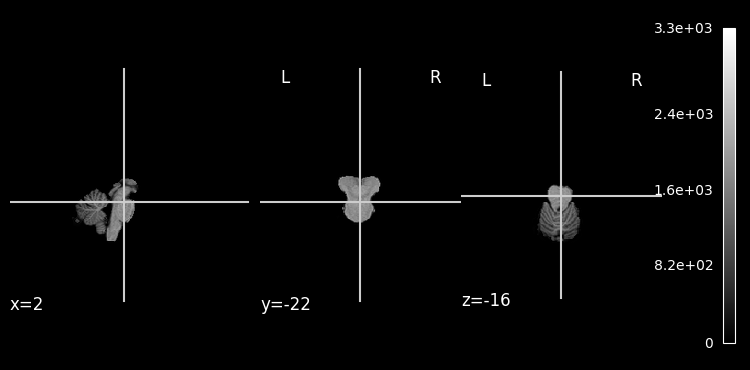

In [27]:
npl.plot_anat(week_cerebel_img)

In [29]:
nib.save(week_cerebel_img, f'{subj_id}_{week}_cerebellum_only_trial.nii.gz')

One potential issue is a difference in voxel size:
- the reference image has voxel 1.2x1x1, but the later week images have voxel 1x1x1.2 - actually, this is just because of rotation. That's fine.

- but we should check the sizes of the images; I think the coregistered image has a different size (in later weeks) from the not-coregistered image. So would we need to use the not-previously-coregistered image?

- In that case, I think we also need to re-segment all the tissue probabilities.